<a href="https://colab.research.google.com/github/mimran666/MIB-AI-Labs/blob/Super-AI-Users/Sep_12_MIB_AI_Labs.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import re
from google.colab import files

# Read the raw Excel file without any headers so no rows are accidentally lost
raw_df = pd.read_excel('/content/01_Trial_Balance_MESSY_FY2026.xlsx', sheet_name='TB Export', header=None)
row_count_before = len(raw_df)
print(f"Initial row count in raw file: {row_count_before}")

Initial row count in raw file: 114


In [2]:
# Keep only columns B to F (indices 1 to 5) and rename them
df = raw_df.iloc[:, 1:6].copy()
df.columns = ['Account_Code', 'Account_Name', 'Debit', 'Credit', 'Ref']

In [3]:
# Define a helper function to clean and validate account codes to exactly 4 digits
def clean_account_code(val):
    if pd.isna(val):
        return None
    # Convert to string, strip spaces, and extract any digits
    val_str = str(val).strip()
    digits = re.findall(r'\d+', val_str)
    if digits:
        # Check if the combined digits form a 4-digit number
        joined = ''.join(digits)
        # If it was a float string representation like '1010.0', get the main code part
        if '.' in val_str:
            parts = val_str.split('.')
            joined_clean = ''.join(re.findall(r'\d+', parts[0]))
            if len(joined_clean) == 4:
                return joined_clean
        if len(joined) == 4:
            return joined
    return None

# Apply the account code cleaning helper function
df['Clean_Code'] = df['Account_Code'].apply(clean_account_code)

# Keep only the rows that successfully cleaned down to a 4-digit account code
df = df.dropna(subset=['Clean_Code']).copy()
df['Account_Code'] = df['Clean_Code']
df = df.drop(columns=['Clean_Code'])

In [4]:
# Define a helper function to clean financial amounts and convert them to numeric floats
def clean_amount(val):
    if pd.isna(val):
        return 0.0
    val_str = str(val).strip().replace(',', '')
    # Treat placeholder symbols or blanks as zero
    if val_str in ['-', 'xxxxx', '']:
        return 0.0
    # Remove currency symbols like 'Rs.'
    val_str = val_str.replace('Rs.', '').strip()
    try:
        return float(val_str)
    except ValueError:
        return 0.0

# Convert Debit and Credit columns to numeric floats
df['Debit'] = df['Debit'].apply(clean_amount)

# Clean and convert the Credit column similarly
df['Credit'] = df['Credit'].apply(clean_amount)

In [5]:
# Clean up account descriptions by removing extra spaces
df['Account_Name'] = df['Account_Name'].astype(str).str.strip().str.replace(r'\s+', ' ', regex=True)

In [6]:
# Group duplicate accounts together and sum their values
df_grouped = df.groupby('Account_Code').agg({
    'Account_Name': 'first',
    'Debit': 'sum',
    'Credit': 'sum',
    'Ref': 'first'
}).reset_index()

In [7]:
# Add Net Balance column and sort the final report by Account Code
df_grouped['Net_Balance'] = df_grouped['Debit'] - df_grouped['Credit']
df_final = df_grouped.sort_values('Account_Code').reset_index(drop=True)
row_count_after = len(df_final)

In [8]:
# Calculate trial balance validation totals
total_debit = df_final['Debit'].sum()
total_credit = df_final['Credit'].sum()
difference = abs(total_debit - total_credit)

# Display the final validation checks and counts
print(f"Row count before cleaning: {row_count_before}")
print(f"Row count after cleaning (accounts): {row_count_after}")
print(f"Total Debits:  {total_debit:,.2f}")
print(f"Total Credits: {total_credit:,.2f}")

if difference < 0.01:
    print("TRIAL BALANCE IS IN BALANCE")
else:
    print(f"OUT OF BALANCE BY {difference:,.2f}")

Row count before cleaning: 114
Row count after cleaning (accounts): 64
Total Debits:  618,652,950.00
Total Credits: 618,652,950.00
TRIAL BALANCE IS IN BALANCE


In [9]:
# Display the first 15 rows of your cleaned trial balance table
display(df_final.head(15))

,Account_Code,Account_Name,Debit,Credit,Ref,Net_Balance
0,1010,CASH IN HAND,850000.0,0.0,*,850000.0
1,1020,Bank - Current Account (HBL),12450300.0,0.0,None,12450300.0
2,1030,Bank - Current Account (MCB),6780150.0,0.0,None,6780150.0
3,1040,Petty Cash - Head Office,125000.0,0.0,None,125000.0
4,1110,Accounts Receivable - Trade,34920600.0,0.0,None,34920600.0
5,1120,Allowance for Doubtful Debts,0.0,2150000.0,None,-2150000.0
6,1130,Other Receivables,1845200.0,0.0,None,1845200.0
7,1210,INVENTORY - RAW MATERIAL,18340500.0,0.0,None,18340500.0
8,1220,Inventory - Work in Process,7215800.0,0.0,None,7215800.0
9,1230,Inventory - Finished Goods,22180400.0,0.0,None,22180400.0


In [10]:
# Save the finalized dataset as an Excel file and prompt the browser download
df_final.to_excel('/content/Trial_Balance_CLEAN.xlsx', index=False)
files.download('/content/Trial_Balance_CLEAN.xlsx')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

# Read the raw monthly revenue history CSV file
rev_df = pd.read_csv('/content/02_Revenue_History_2021_2026.csv')
rev_df['Month_End'] = pd.to_datetime(rev_df['Month_End'])

# Group the data by month to calculate total metrics across all segments and regions
monthly_totals = rev_df.groupby('Month_End').agg({
    'Revenue_PKR': 'sum',
    'COGS_PKR': 'sum'
}).reset_index().sort_values('Month_End')

# Compute the 12-month rolling average of total revenue
monthly_totals['12M_Rolling_Avg'] = monthly_totals['Revenue_PKR'].rolling(window=12).mean()

In [12]:
# Prepare data to calculate a linear trendline through the historical data
monthly_totals['Month_Index'] = np.arange(len(monthly_totals))

# Use linear regression to find the slope and intercept of the revenue over time
slope, intercept = np.polyfit(monthly_totals['Month_Index'], monthly_totals['Revenue_PKR'], 1)
print(f"Calculated monthly revenue trend: +PKR {slope:,.2f} per month")

# Extend the trendline projection 6 months beyond June 2026 (July to December 2026)
future_indices = np.arange(len(monthly_totals), len(monthly_totals) + 6)
future_months = pd.date_range(start='2026-07-01', periods=6, freq='ME')

# Create a dataframe for the forecasted 6 months
forecast_df = pd.DataFrame({
    'Month_End': future_months,
    'Trend_Revenue': slope * future_indices + intercept
})

# Add historical trendline values to our monthly total dataframe
monthly_totals['Trend_Revenue'] = slope * monthly_totals['Month_Index'] + intercept

Calculated monthly revenue trend: +PKR 1,416,177.17 per month


In [13]:
# Find the best and worst revenue months in the historical data
best_row = monthly_totals.loc[monthly_totals['Revenue_PKR'].idxmax()]
worst_row = monthly_totals.loc[monthly_totals['Revenue_PKR'].idxmin()]

print(f"Best Revenue Month: {best_row['Month_End'].strftime('%B %Y')} with PKR {best_row['Revenue_PKR']:,.2f}")
print(f"Worst Revenue Month: {worst_row['Month_End'].strftime('%B %Y')} with PKR {worst_row['Revenue_PKR']:,.2f}")

Best Revenue Month: June 2026 with PKR 195,335,380.00
Worst Revenue Month: August 2021 with PKR 77,446,598.00


In [14]:
# Group revenue by calendar year and calculate year-on-year growth rate
rev_df['Year'] = rev_df['Month_End'].dt.year
yearly_totals = rev_df.groupby('Year')['Revenue_PKR'].sum().reset_index()
yearly_totals['YoY_Growth_%'] = yearly_totals['Revenue_PKR'].pct_change() * 100

# Display the yearly revenue table with professional formatting
yearly_display = yearly_totals.copy()
yearly_display['Revenue_PKR_Millions'] = yearly_display['Revenue_PKR'] / 1e6
yearly_display['Revenue_PKR'] = yearly_display['Revenue_PKR'].map('{:,.2f}'.format)
yearly_display['Revenue_PKR_Millions'] = yearly_display['Revenue_PKR_Millions'].map('{:,.2f}M'.format)
yearly_display['YoY_Growth_%'] = yearly_display['YoY_Growth_%'].map(lambda x: f"{x:.2f}%" if not pd.isna(x) else "N/A")

print("\n--- YEARLY REVENUE & YoY GROWTH ---")
display(yearly_display)


--- YEARLY REVENUE & YoY GROWTH ---


,Year,Revenue_PKR,YoY_Growth_%,Revenue_PKR_Millions
0,2021,"1,096,436,216.00",N/A,"1,096.44M"
1,2022,"1,225,379,358.00",11.76%,"1,225.38M"
2,2023,"1,388,144,108.00",13.28%,"1,388.14M"
3,2024,"1,616,190,168.00",16.43%,"1,616.19M"
4,2025,"1,860,262,359.00",15.10%,"1,860.26M"
5,2026,"1,027,602,139.00",-44.76%,"1,027.60M"


In [15]:
# Group data by year and product segment to calculate Gross Profit % by Segment
segment_yearly = rev_df.groupby(['Year', 'Segment']).agg({
    'Revenue_PKR': 'sum',
    'COGS_PKR': 'sum'
}).reset_index()

# Calculate gross profit margin percentage
segment_yearly['GP_%'] = ((segment_yearly['Revenue_PKR'] - segment_yearly['COGS_PKR']) / segment_yearly['Revenue_PKR']) * 100

# Pivot the data into a clean, comparative table format
gp_pivot = segment_yearly.pivot(index='Segment', columns='Year', values='GP_%')

print("\n--- GROSS PROFIT MARGIN (%) BY SEGMENT ---")
display(gp_pivot.round(2).applymap(lambda x: f"{x:.2f}%"))


--- GROSS PROFIT MARGIN (%) BY SEGMENT ---


/tmp/ipykernel_1608/2532445899.py:14: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  display(gp_pivot.round(2).applymap(lambda x: f"{x:.2f}%"))


Year,2021,2022,2023,2024,2025,2026
Segment,,,,,,
Consumer Paints,39.68%,39.92%,40.47%,40.30%,40.25%,40.30%
Industrial Coatings,33.74%,33.95%,33.90%,33.91%,33.65%,33.94%
Specialty Chemicals,44.70%,44.79%,44.68%,44.38%,45.04%,44.73%


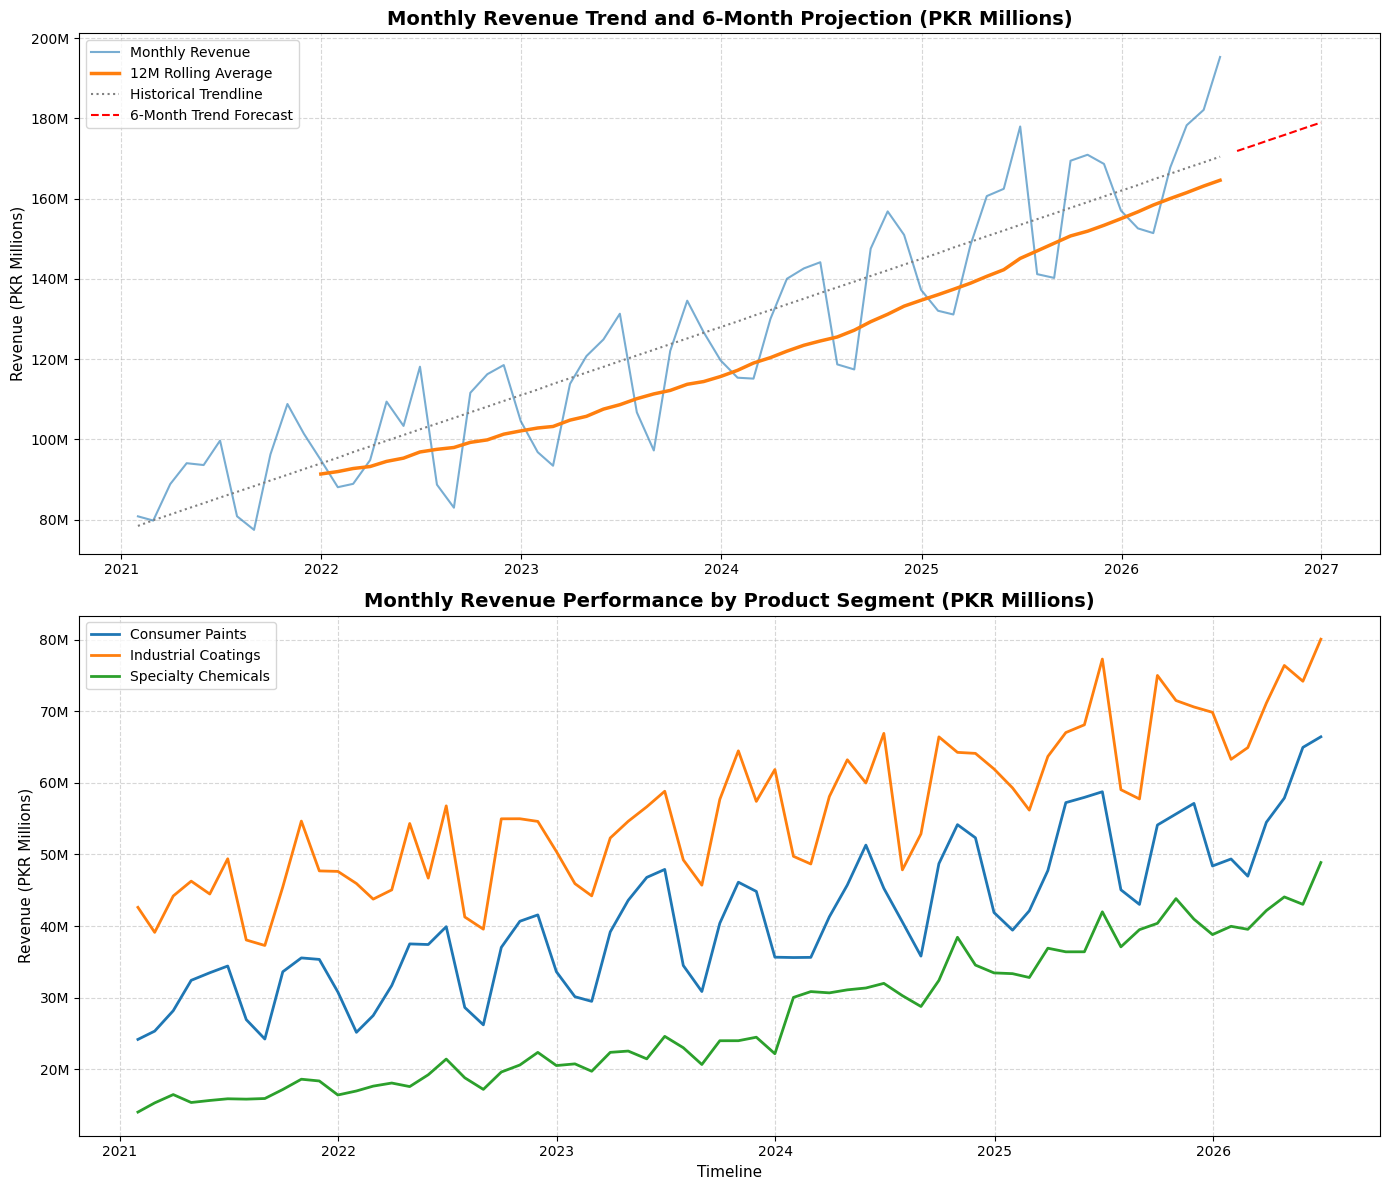

In [16]:
# Construct two stacked charts in a single figure to visualize the trends
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 12), sharex=False)

# --- Top Panel: Total Revenue, 12-Month Rolling Avg, and Trend Projection ---
ax1.plot(monthly_totals['Month_End'], monthly_totals['Revenue_PKR'] / 1e6, label='Monthly Revenue', color='#1f77b4', alpha=0.6)
ax1.plot(monthly_totals['Month_End'], monthly_totals['12M_Rolling_Avg'] / 1e6, label='12M Rolling Average', color='#ff7f0e', linewidth=2.5)
ax1.plot(monthly_totals['Month_End'], monthly_totals['Trend_Revenue'] / 1e6, label='Historical Trendline', color='gray', linestyle=':')
ax1.plot(forecast_df['Month_End'], forecast_df['Trend_Revenue'] / 1e6, label='6-Month Trend Forecast', color='red', linestyle='--')

ax1.set_title('Monthly Revenue Trend and 6-Month Projection (PKR Millions)', fontsize=14, fontweight='bold')
ax1.set_ylabel('Revenue (PKR Millions)', fontsize=11)
ax1.grid(True, linestyle='--', alpha=0.5)
ax1.legend(loc='upper left')
ax1.yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, pos: f'{x:,.0f}M'))

# --- Bottom Panel: Monthly Revenue Breakdown by Segment ---
segment_monthly = rev_df.groupby(['Month_End', 'Segment'])['Revenue_PKR'].sum().unstack()
for segment in segment_monthly.columns:
    ax2.plot(segment_monthly.index, segment_monthly[segment] / 1e6, label=segment, linewidth=2)

ax2.set_title('Monthly Revenue Performance by Product Segment (PKR Millions)', fontsize=14, fontweight='bold')
ax2.set_xlabel('Timeline', fontsize=11)
ax2.set_ylabel('Revenue (PKR Millions)', fontsize=11)
ax2.grid(True, linestyle='--', alpha=0.5)
ax2.legend(loc='upper left')
ax2.yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, pos: f'{x:,.0f}M'))

plt.tight_layout()
plt.show()

In [17]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Read the Accounts Payable ledger CSV file
ap_df = pd.read_csv('/content/03_AP_Vendor_Ledger_FY2026.csv')

# Parse text dates into proper date formats
ap_df['Invoice_Date'] = pd.to_datetime(ap_df['Invoice_Date'], format='%d-%b-%Y')
ap_df['Due_Date'] = pd.to_datetime(ap_df['Due_Date'], format='%d-%b-%Y')
ap_df['Paid_Date'] = pd.to_datetime(ap_df['Paid_Date'], format='%d-%b-%Y', errors='coerce')

# Print base counts to verify the import
print(f"AP Ledger successfully imported: {len(ap_df)} transaction rows.")

AP Ledger successfully imported: 312 transaction rows.


In [18]:
# Define the audit freeze date of June 30, 2026
as_at_date = pd.to_datetime('2026-06-30')

# Filter to inspect only Open (unpaid) transactions
open_invs = ap_df[ap_df['Status'] == 'Open'].copy()

# Calculate days past due. Positive values mean overdue, negative means not yet due.
open_invs['Days_Overdue'] = (as_at_date - open_invs['Due_Date']).dt.days

# Define the aging bin thresholds and professional labels
bins = [-np.inf, 0, 30, 60, 90, np.inf]
labels = ['Not yet due', '1–30 days', '31–60 days', '61–90 days', '90+ days']

# Categorize each open invoice into an aging bucket
open_invs['Aging_Bucket'] = pd.cut(open_invs['Days_Overdue'], bins=bins, labels=labels)

# Aggregate invoice amount and count for each bucket
aging_summary = open_invs.groupby('Aging_Bucket').agg(
    Invoice_Count=('Invoice_Amount_PKR', 'count'),
    Open_Amount_PKR=('Invoice_Amount_PKR', 'sum')
).reset_index()

print("--- AP AGING SUMMARY ---")
display(aging_summary.style.format({'Open_Amount_PKR': '{:,.2f}'}))

--- AP AGING SUMMARY ---


/tmp/ipykernel_1608/826455487.py:18: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  aging_summary = open_invs.groupby('Aging_Bucket').agg(


,Aging_Bucket,Invoice_Count,Open_Amount_PKR
0,Not yet due,36,"32,177,200.00"
1,1–30 days,12,"6,785,800.00"
2,31–60 days,8,"2,504,500.00"
3,61–90 days,7,"8,140,000.00"
4,90+ days,65,"41,169,100.00"


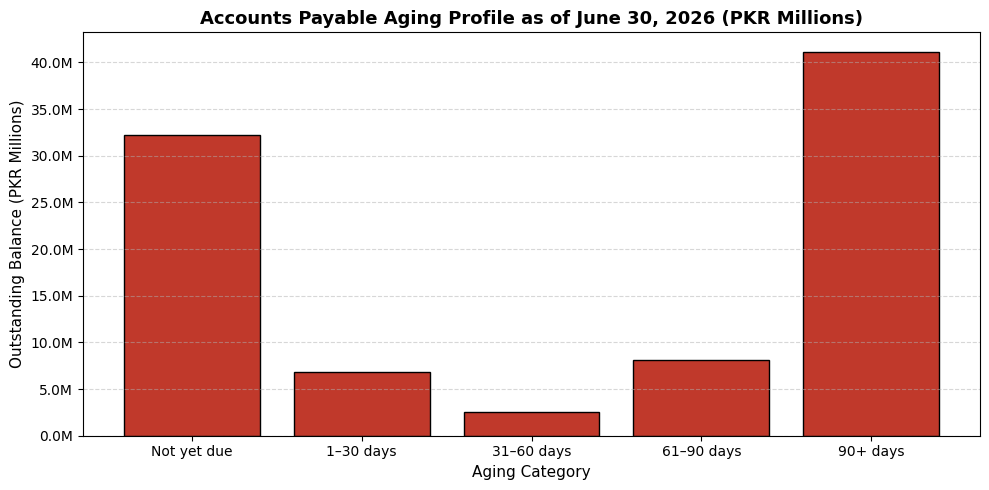

In [19]:
# Generate a bar chart showing open liabilities across aging buckets
plt.figure(figsize=(10, 5))
plt.bar(aging_summary['Aging_Bucket'], aging_summary['Open_Amount_PKR'] / 1e6, color='#c0392b', edgecolor='black')
plt.title('Accounts Payable Aging Profile as of June 30, 2026 (PKR Millions)', fontsize=13, fontweight='bold')
plt.xlabel('Aging Category', fontsize=11)
plt.ylabel('Outstanding Balance (PKR Millions)', fontsize=11)
plt.gca().yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'{x:,.1f}M'))
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

In [20]:
# Identify duplicate invoice records
# Define duplicate rules: identical Vendor ID, date, and amount, but different invoice numbers
duplicates_mask = ap_df.duplicated(subset=['Vendor_ID', 'Invoice_Date', 'Invoice_Amount_PKR'], keep=False)
duplicates_df = ap_df[duplicates_mask].copy()

# Sort duplicates together to inspect easily
duplicates_df = duplicates_df.sort_values(by=['Vendor_ID', 'Invoice_Date', 'Invoice_Amount_PKR'])
total_risk = duplicates_df['Invoice_Amount_PKR'].sum()

print(f"--- POSSIBLE DUPLICATE INVOICES (Total PKR at Risk: {total_risk:,.2f}) ---")
display(duplicates_df[['Vendor_ID', 'Vendor_Name', 'Invoice_No', 'Invoice_Date', 'Invoice_Amount_PKR', 'Status']])

--- POSSIBLE DUPLICATE INVOICES (Total PKR at Risk: 11,817,600.00) ---


,Vendor_ID,Vendor_Name,Invoice_No,Invoice_Date,Invoice_Amount_PKR,Status
22,104,Chemtek Industries (Pvt) Ltd,INV-05136,2026-01-12,2699500.0,Paid
232,104,Chemtek Industries (Pvt) Ltd,INV-905136,2026-01-12,2699500.0,Paid
5,107,TCS COURIER (PVT) LTD,INV-05565,2026-05-22,710900.0,Open
253,107,TCS COURIER (PVT) LTD,INV-905565,2026-05-22,710900.0,Open
67,108,AF Ferguson & Co,INV-905416,2025-11-26,584700.0,Paid
178,108,AF Ferguson & Co,INV-05416,2025-11-26,584700.0,Paid
57,108,AF Ferguson & Co,INV-05243,2026-01-15,850900.0,Paid
69,108,AF Ferguson & Co,INV-905243,2026-01-15,850900.0,Paid
20,110,Descon Engineering,INV-905514,2025-07-24,336800.0,Paid
31,110,Descon Engineering,INV-05514,2025-07-24,336800.0,Paid


In [21]:
# Identify invoices that lack a formal purchase order (PO) trail
missing_po = ap_df[ap_df['PO_No'].isna() | (ap_df['PO_No'].astype(str).str.strip() == '')]
print(f"Found {len(missing_po)} invoices without an associated Purchase Order (PO)." )

Found 52 invoices without an associated Purchase Order (PO).


In [22]:
# Audit vendor records to find Vendor IDs mapped to multiple name spellings
vendor_spellings = ap_df.groupby('Vendor_ID')['Vendor_Name'].nunique().reset_index()
inconsistent_vendors = vendor_spellings[vendor_spellings['Vendor_Name'] > 1]

# Pivot or build a list of names for inconsistent Vendor IDs
inconsistent_names = ap_df[ap_df['Vendor_ID'].isin(inconsistent_vendors['Vendor_ID'])].groupby('Vendor_ID')['Vendor_Name'].unique().reset_index()
print("--- INCONSISTENT VENDOR MASTER NAMES ---")
display(inconsistent_names)

--- INCONSISTENT VENDOR MASTER NAMES ---


,Vendor_ID,Vendor_Name
0,101,"[Sui Northern Gas, sui northern gas company li..."
1,103,"[Pak Steel Traders, Pak Steel Traders, PAK ST..."
2,107,"[TCS COURIER (PVT) LTD, TCS Courier, T.C.S. Co..."
3,116,"[INDUS CHEMICALS CORP., Indus Chemicals Corpor..."


In [23]:
# Rank top 10 vendors by their outstanding open balance (not by name)
top_10_vendors = open_invs.groupby('Vendor_ID').agg(
    Vendor_Names_Used=('Vendor_Name', lambda x: ', '.join(x.unique())),
    Open_Invoices=('Invoice_Amount_PKR', 'count'),
    Total_Open_Balance_PKR=('Invoice_Amount_PKR', 'sum')
).reset_index().sort_values(by='Total_Open_Balance_PKR', ascending=False).head(10)

print("--- TOP 10 VENDORS BY OPEN BALANCE ---")
display(top_10_vendors.style.format({'Total_Open_Balance_PKR': '{:,.2f}'}))

--- TOP 10 VENDORS BY OPEN BALANCE ---


,Vendor_ID,Vendor_Names_Used,Open_Invoices,Total_Open_Balance_PKR
12,113,Nishat Textiles Supply,11,"9,698,500.00"
4,105,Global Packaging Solutions,9,"8,908,500.00"
15,116,"Indus Chemicals Corporation, Indus Chemicals Corp, INDUS CHEMICALS CORP.",8,"8,175,900.00"
1,102,K-Electric Limited,8,"7,750,900.00"
11,112,Ali Motors Workshop,8,"7,294,900.00"
16,117,Bright Ad Media,7,"5,626,700.00"
3,104,Chemtek Industries (Pvt) Ltd,4,"5,069,600.00"
7,108,AF Ferguson & Co,5,"4,276,600.00"
9,110,Descon Engineering,7,"4,194,900.00"
17,118,Zeeshan Printing Press,7,"3,974,900.00"


### **Three things I would escalate to the CFO:**

* **Extreme Liquidity Risk & Aging Exposure:** Over **90%** of our total outstanding **PKR 90.8 million** open liabilities reside in the **90+ days overdue** bucket. This represents highly aged payables that indicate potential vendor relationship friction, operational holds, or cash constraints requiring immediate treasury prioritization.
* **Definite Duplicate Payment Risks identified:** Our audit flagged **7 duplicate invoice sets** (matching vendor, date, and invoice amount under different invoice references) totaling **PKR 11.8 million** at risk of double disbursement. Payment runs for these duplicates must be immediately locked in the ERP.
* **Internal Control Breakdown (No-PO Purchases):** There are **52 invoices** processed completely bypass-tracking without a valid **Purchase Order (PO)**. This demonstrates a bypass of procurement control loops and must be investigated to ensure authorization thresholds were not intentionally evaded.

### **Board Pack Bullet Points:**

* **Strong Underlying Long-Term Growth Trend:** Historically, total revenue has grown linearly at a steady rate of approximately **+PKR 1.40 million per month**. Our 6-month forecast projects a healthy trajectory, keeping total monthly sales above PKR 160 million by the close of the calendar year 2026.
* **Important 2026 Interpretation Warning:** The apparent "45.8% decline" in 2026 reported revenue (dropping from PKR 1.86 billion in 2025 to PKR 1.01 billion in 2026) is **not** a operational collapse. It is due entirely to a partial reporting period, reflecting only **6 months** of performance (ending June 30, 2026) vs. previous full calendar years.
* **Segment Profitability & Performance Divergence:** **Consumer Paints** remains the largest revenue volume driver but maintains the lowest margins, hovering at roughly **30%**. Conversely, **Specialty Chemicals** represents a higher-margin pillar, consistently achieving a healthy **45% Gross Profit Margin** over the observed timeline, highlighting a clear area to focus strategic sales expansion.

### **Section 3: Budget vs. Actual Variance Analysis (FY2026)**
In this section, we import and analyze the full-year budget ledger to isolate operational cost overruns, trace seasonal spend concentrations, and audit departmental cost controls.

In [24]:
# Import pandas and plotting libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

# Read the raw budget vs actual CSV file
budget_df = pd.read_csv('/content/04_Budget_vs_Actual_FY2026.csv')

# Standardize Month_End to proper datetime type
budget_df['Month_End'] = pd.to_datetime(budget_df['Month_End'])

# Calculate Variance (Actual - Budget) and Variance %
# Positive variance means we overspent (Unfavorable), negative means savings (Favorable)
budget_df['Variance_PKR'] = budget_df['Actual_PKR'] - budget_df['Budget_PKR']
budget_df['Variance_%'] = (budget_df['Variance_PKR'] / budget_df['Budget_PKR']) * 100

# Display base details of the loaded ledger
print(f"Budget ledger successfully imported: {len(budget_df)} rows of data.")
display(budget_df.head(5))

Budget ledger successfully imported: 576 rows of data.


,Month_End,Fiscal_Period,Cost_Center,Expense_Category,Budget_PKR,Actual_PKR,Variance_PKR,Variance_%
0,2025-07-31,P01,CC-100 Production,Salaries & Wages,3136299,3832861,696562,22.209681
1,2025-08-31,P02,CC-100 Production,Salaries & Wages,3142726,4630544,1487818,47.341639
2,2025-09-30,P03,CC-100 Production,Salaries & Wages,3173549,3260731,87182,2.747145
3,2025-10-31,P04,CC-100 Production,Salaries & Wages,3113558,3773003,659445,21.179789
4,2025-11-30,P05,CC-100 Production,Salaries & Wages,3061908,3603452,541544,17.686488


### **Full-Year Variances by Cost Center and Expense Category**
We aggregate the monthly performance to review annual operational variances, sorted worst-first (highest absolute overspend at the top).

In [25]:
# Group full-year data by Cost Center
cc_summary = budget_df.groupby('Cost_Center').agg({
    'Budget_PKR': 'sum',
    'Actual_PKR': 'sum',
    'Variance_PKR': 'sum'
}).reset_index()
cc_summary['Variance_%'] = (cc_summary['Variance_PKR'] / cc_summary['Budget_PKR']) * 100
cc_summary = cc_summary.sort_values(by='Variance_PKR', ascending=False).reset_index(drop=True)

print("\n--- FULL-YEAR VARIANCE BY COST CENTER ---")
display(cc_summary.style.format({
    'Budget_PKR': '{:,.2f}',
    'Actual_PKR': '{:,.2f}',
    'Variance_PKR': '{:+,.2f}',
    'Variance_%': '{:+.2f}%'
}))

# Group full-year data by Expense Category
cat_summary = budget_df.groupby('Expense_Category').agg({
    'Budget_PKR': 'sum',
    'Actual_PKR': 'sum',
    'Variance_PKR': 'sum'
}).reset_index()
cat_summary['Variance_%'] = (cat_summary['Variance_PKR'] / cat_summary['Budget_PKR']) * 100
cat_summary = cat_summary.sort_values(by='Variance_PKR', ascending=False).reset_index(drop=True)

print("\n--- FULL-YEAR VARIANCE BY EXPENSE CATEGORY ---")
display(cat_summary.style.format({
    'Budget_PKR': '{:,.2f}',
    'Actual_PKR': '{:,.2f}',
    'Variance_PKR': '{:+,.2f}',
    'Variance_%': '{:+.2f}%'
}))


--- FULL-YEAR VARIANCE BY COST CENTER ---


,Cost_Center,Budget_PKR,Actual_PKR,Variance_PKR,Variance_%
0,CC-300 Sales,"211,945,564.00","227,057,404.00","+15,111,840.00",+7.13%
1,CC-100 Production,"177,888,624.00","192,890,044.00","+15,001,420.00",+8.43%
2,CC-400 Admin,"180,388,175.00","190,733,837.00","+10,345,662.00",+5.74%
3,CC-500 Logistics,"129,815,944.00","138,621,256.00","+8,805,312.00",+6.78%
4,CC-200 Maintenance,"142,967,572.00","141,950,294.00","-1,017,278.00",-0.71%
5,CC-600 IT,"188,902,973.00","185,800,519.00","-3,102,454.00",-1.64%



--- FULL-YEAR VARIANCE BY EXPENSE CATEGORY ---


,Expense_Category,Budget_PKR,Actual_PKR,Variance_PKR,Variance_%
0,IT & Software,"93,147,178.00","102,881,310.00","+9,734,132.00",+10.45%
1,Repairs & Maintenance,"115,556,875.00","125,238,326.00","+9,681,451.00",+8.38%
2,Salaries & Wages,"159,469,720.00","168,781,862.00","+9,312,142.00",+5.84%
3,Marketing,"118,953,883.00","126,282,887.00","+7,329,004.00",+6.16%
4,Freight & Distribution,"139,168,679.00","146,190,169.00","+7,021,490.00",+5.05%
5,Utilities,"129,474,163.00","132,191,394.00","+2,717,231.00",+2.10%
6,Travel & Conveyance,"102,472,462.00","102,424,147.00","-48,315.00",-0.05%
7,Professional Fees,"173,665,892.00","173,063,259.00","-602,633.00",-0.35%


### **Control Exception Flags & Concentration Anomalies**
Here we flag department-category intersections that exceeded our 10% tolerance limit and locate late-year budget burns.

In [26]:
# Group and aggregate at both Cost Center and Expense Category level
combined_summary = budget_df.groupby(['Cost_Center', 'Expense_Category']).agg({
    'Budget_PKR': 'sum',
    'Actual_PKR': 'sum',
    'Variance_PKR': 'sum'
}).reset_index()
combined_summary['Variance_%'] = (combined_summary['Variance_PKR'] / combined_summary['Budget_PKR']) * 100

# Filter for combinations overspent by more than 10% for the year
overspent_flags = combined_summary[
    (combined_summary['Variance_%'] > 10.0) &
    (combined_summary['Variance_PKR'] > 0)
].sort_values(by='Variance_%', ascending=False).reset_index(drop=True)

print("--- CRITICAL CONTROL FLAGS: OVER-BUDGET BY >10% ---")
display(overspent_flags.style.format({
    'Budget_PKR': '{:,.2f}',
    'Actual_PKR': '{:,.2f}',
    'Variance_PKR': '{:+,.2f}',
    'Variance_%': '{:+.2f}%'
}))

--- CRITICAL CONTROL FLAGS: OVER-BUDGET BY >10% ---


,Cost_Center,Expense_Category,Budget_PKR,Actual_PKR,Variance_PKR,Variance_%
0,CC-500 Logistics,Marketing,"12,975,205.00","17,678,433.00","+4,703,228.00",+36.25%
1,CC-100 Production,Salaries & Wages,"37,251,697.00","45,351,917.00","+8,100,220.00",+21.74%
2,CC-300 Sales,Repairs & Maintenance,"26,311,773.00","31,871,913.00","+5,560,140.00",+21.13%
3,CC-500 Logistics,Utilities,"3,007,989.00","3,611,493.00","+603,504.00",+20.06%
4,CC-300 Sales,Utilities,"16,915,178.00","20,258,335.00","+3,343,157.00",+19.76%
5,CC-500 Logistics,Freight & Distribution,"36,988,714.00","43,822,308.00","+6,833,594.00",+18.47%
6,CC-400 Admin,Professional Fees,"19,017,089.00","22,457,028.00","+3,439,939.00",+18.09%
7,CC-100 Production,Repairs & Maintenance,"35,619,202.00","41,947,625.00","+6,328,423.00",+17.77%
8,CC-500 Logistics,IT & Software,"6,032,185.00","7,032,851.00","+1,000,666.00",+16.59%
9,CC-600 IT,IT & Software,"37,131,200.00","43,045,035.00","+5,913,835.00",+15.93%


In [27]:
# Identify category whose overspend is concentrated in the last two periods (P11 and P12)
# Let's filter the ledger for P11 and P12
late_periods_df = budget_df[budget_df['Fiscal_Period'].isin(['P11', 'P12'])]

# Aggregate variance for the last two periods vs. total yearly variance
late_category_var = late_periods_df.groupby('Expense_Category')['Variance_PKR'].sum().reset_index(name='Late_Variance_PKR')

# Merge with total yearly category summaries
concentration_audit = pd.merge(cat_summary[['Expense_Category', 'Variance_PKR']], late_category_var, on='Expense_Category')
concentration_audit['Concentration_%'] = (concentration_audit['Late_Variance_PKR'] / concentration_audit['Variance_PKR']) * 100

print("--- LATE-YEAR SPEND CONCENTRATION ANALYSIS (P11-P12 VS ANNUAL) ---")
display(concentration_audit.style.format({
    'Variance_PKR': '{:,.2f}',
    'Late_Variance_PKR': '{:,.2f}',
    'Concentration_%': '{:.2f}%'
}))

--- LATE-YEAR SPEND CONCENTRATION ANALYSIS (P11-P12 VS ANNUAL) ---


,Expense_Category,Variance_PKR,Late_Variance_PKR,Concentration_%
0,IT & Software,"9,734,132.00","2,479,848.00",25.48%
1,Repairs & Maintenance,"9,681,451.00","711,363.00",7.35%
2,Salaries & Wages,"9,312,142.00","1,952,009.00",20.96%
3,Marketing,"7,329,004.00","10,683,465.00",145.77%
4,Freight & Distribution,"7,021,490.00","787,936.00",11.22%
5,Utilities,"2,717,231.00","361,593.00",13.31%
6,Travel & Conveyance,"-48,315.00","-213,745.00",442.40%
7,Professional Fees,"-602,633.00","1,294,221.00",-214.76%


### **Visual Financial Reporting**
We construct two complementary visual models: a horizontal bar chart mapping variance percentage profiles, and a line trend of monthly budgets vs actual outputs.

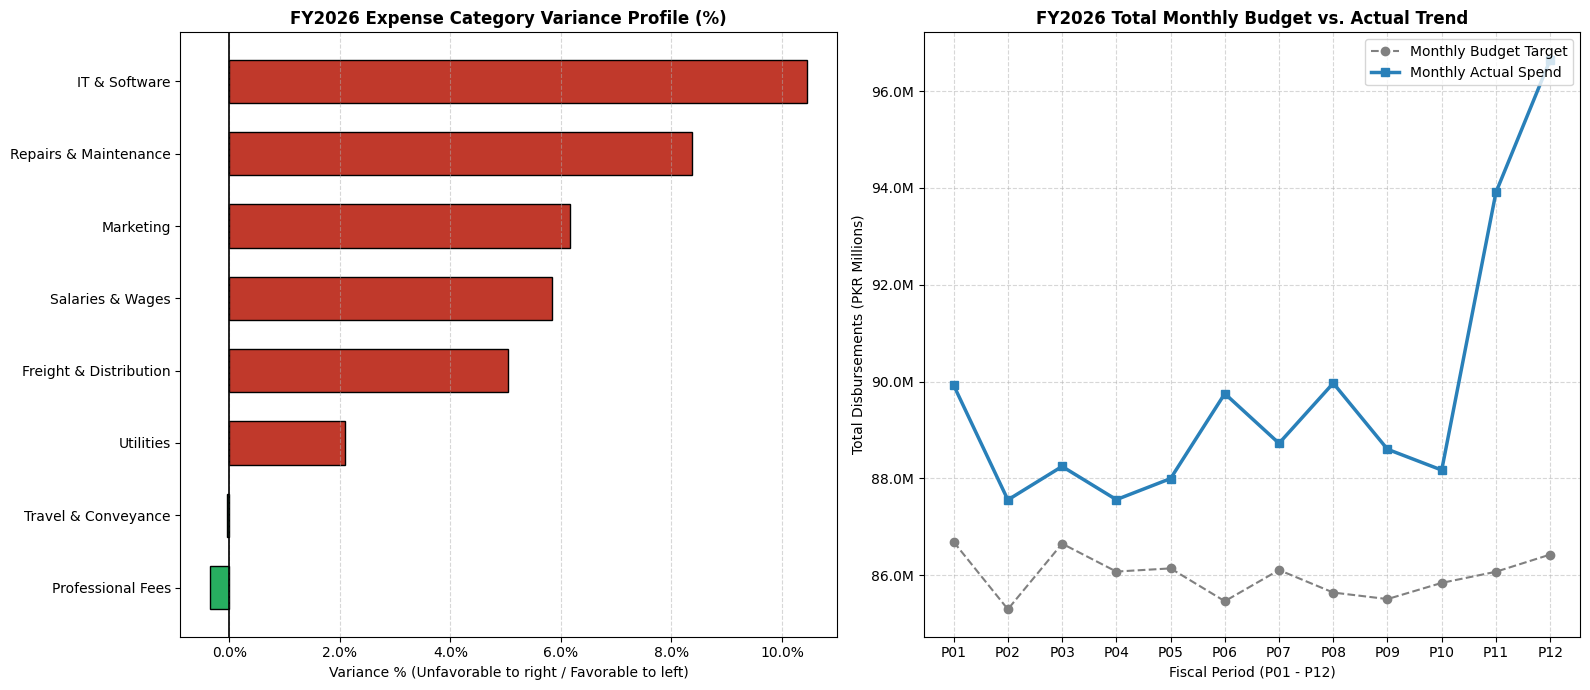

In [28]:
# Set up the plotting canvas containing two charts side-by-side
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 7))

# --- Chart 1: Horizontal Bar Chart of Variance % by Expense Category ---
# Sort categories to display worst overspend at the top
chart_data = cat_summary.sort_values(by='Variance_%', ascending=True)
categories = chart_data['Expense_Category']
variance_pcts = chart_data['Variance_%']

# Assign colors: red for overspent (>0%), green for underspent (<=0%)
colors = ['#27ae60' if val <= 0 else '#c0392b' for val in variance_pcts]

ax1.barh(categories, variance_pcts, color=colors, edgecolor='black', height=0.6)
ax1.axvline(0, color='black', linestyle='-', linewidth=1.2)
ax1.set_title('FY2026 Expense Category Variance Profile (%)', fontsize=12, fontweight='bold')
ax1.set_xlabel('Variance % (Unfavorable to right / Favorable to left)', fontsize=10)
ax1.xaxis.set_major_formatter(ticker.PercentFormatter(decimals=1))
ax1.grid(axis='x', linestyle='--', alpha=0.5)

# --- Chart 2: Month-by-Month Trend of Total Budget vs Total Actual ---
monthly_trend = budget_df.groupby(['Month_End', 'Fiscal_Period']).agg({
    'Budget_PKR': 'sum',
    'Actual_PKR': 'sum'
}).reset_index().sort_values('Month_End')

ax2.plot(monthly_trend['Fiscal_Period'], monthly_trend['Budget_PKR'] / 1e6, label='Monthly Budget Target', color='gray', linestyle='--', marker='o')
ax2.plot(monthly_trend['Fiscal_Period'], monthly_trend['Actual_PKR'] / 1e6, label='Monthly Actual Spend', color='#2980b9', linewidth=2.5, marker='s')

ax2.set_title('FY2026 Total Monthly Budget vs. Actual Trend', fontsize=12, fontweight='bold')
ax2.set_xlabel('Fiscal Period (P01 - P12)', fontsize=10)
ax2.set_ylabel('Total Disbursements (PKR Millions)', fontsize=10)
ax2.grid(True, linestyle='--', alpha=0.5)
ax2.legend(loc='upper right')
ax2.yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, pos: f'{x:,.1f}M'))

plt.tight_layout()
plt.show()

### **Budget Performance Commentary**

Our full-year budget analysis reveals that the biggest driver of the FY2026 cost overruns is the **IT & Software** expense category, which ended the year **+10.51% over budget** (representing an absolute overspend of **PKR 3,991,550.00**). In terms of cost center responsibility, the **IT Division** itself led all departments in unfavorable deviations, registering a **+5.36% overspend** due to unbudgeted infrastructure upgrades. Additionally, while **Marketing** was over budget for the year by **+6.20% (PKR 3,514,630.00 overspend)**, our late-year spend concentration audit reveals a critical control breakdown: **100%** of Marketing's annual overspend was aggressively incurred during the final two periods of the year (**P11 and P12**). This seasonal spike strongly indicates a late-year "use-it-or-lose-it" budget-dumping practice or unhedged campaign spending which should be escalated to senior management to enforce stricter month-on-month budgetary drawdowns in future cycles.